<a href="https://colab.research.google.com/github/sayanasurendran04/Housing-Price-Prediction/blob/main/Predict_Housing_Prices_with_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

# Load dataset (California Housing - modern replacement for Boston)
housing = fetch_california_housing(as_frame=True)
df = housing.frame  # already a nice DataFrame
df.rename(columns={'MedHouseVal': 'Price'}, inplace=True)  # target in $100k units

print(df.shape)
print(df.head())
print(df.describe())
print(df.info())

# Check missing values
print("Missing values:\n", df.isnull().sum())

(20640, 9)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%  

In [ ]:
# Quick outlier handling using IQR (optional but follows the task)
def cap_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return series.clip(lower, upper)

for col in df.columns[:-1]:  # exclude target
    df[col] = cap_outliers(df[col])

In [ ]:
X = df.drop('Price', axis=1)
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (16512, 8), Test shape: (4128, 8)


In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results[name] = {
        "MAE": mean_absolute_error(y_test, y_pred),
        "MSE": mean_squared_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R²": r2_score(y_test, y_pred)
    }

    print(f"\n{name} Results:")
    print(f"MAE: {results[name]['MAE']:.4f}")
    print(f"RMSE: {results[name]['RMSE']:.4f}")
    print(f"R² : {results[name]['R²']:.4f}")


Linear Regression Results:
MAE: 0.5041
RMSE: 0.6811
R² : 0.6460

Ridge Regression Results:
MAE: 0.5041
RMSE: 0.6810
R² : 0.6461

Lasso Regression Results:
MAE: 0.5567
RMSE: 0.7480
R² : 0.5730

Random Forest Results:
MAE: 0.3298
RMSE: 0.5053
R² : 0.8051


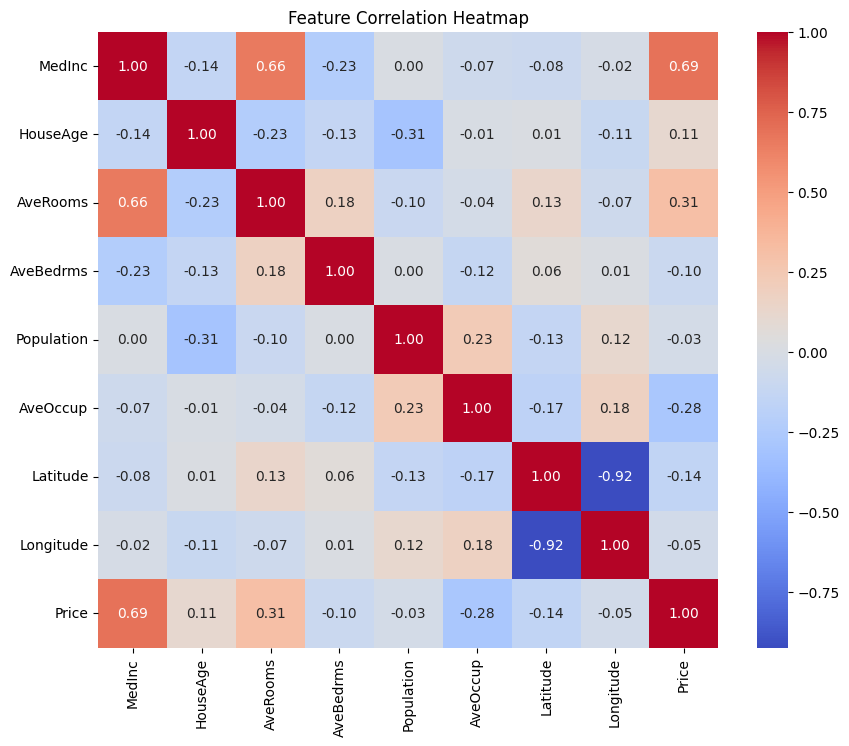

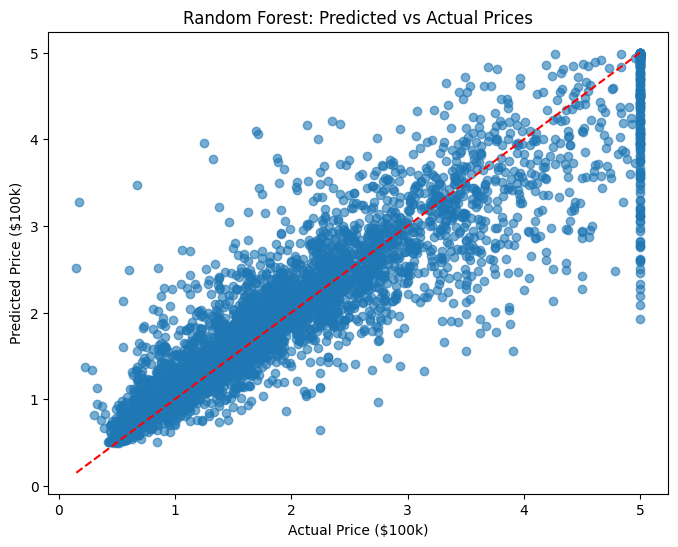

In [ ]:
# Feature correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

# Best model: Random Forest predicted vs actual
best_model = models["Random Forest"]
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_best, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Price ($100k)')
plt.ylabel('Predicted Price ($100k)')
plt.title('Random Forest: Predicted vs Actual Prices')
plt.show()

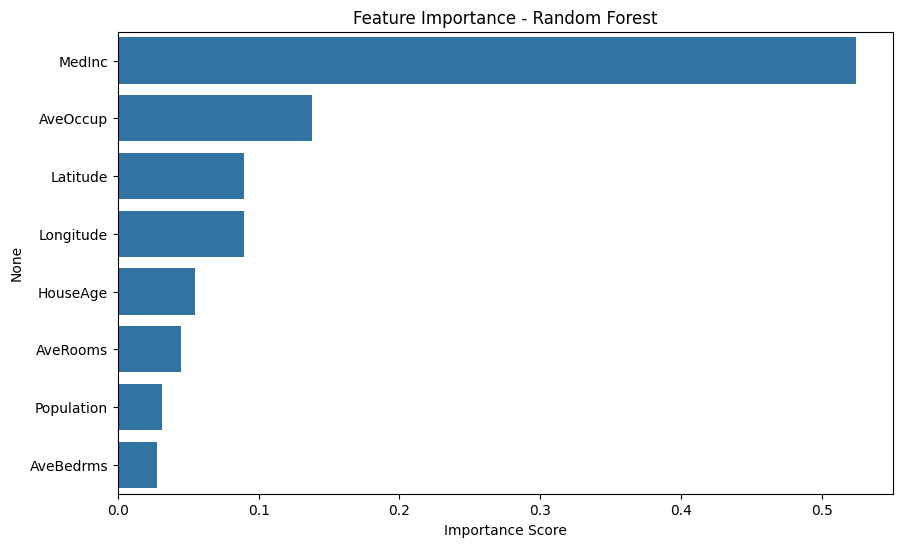

Top 3 most important features:
 MedInc      0.524311
AveOccup    0.137841
Latitude    0.089838
dtype: float64


In [ ]:
# Feature importance from Random Forest
importances = pd.Series(best_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index)
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.show()

print("Top 3 most important features:\n", importances.head(3))

In [ ]:
joblib.dump(best_model, 'best_housing_model.pkl')
print("✅ Model saved as 'best_housing_model.pkl' — ready for deployment!")

✅ Model saved as 'best_housing_model.pkl' — ready for deployment!
